In [3]:
import numpy as np

import pandas as pd

columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv("./diabetes.csv",  names=columns)


بررسی وجود صفر نامعتبر        

In [4]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_cols:
    n_zeros = (df[col] == 0).sum()
    print(f"{col}: {n_zeros} مقدار صفر")

 


Glucose: 0 مقدار صفر
BloodPressure: 0 مقدار صفر
SkinThickness: 0 مقدار صفر
Insulin: 0 مقدار صفر
BMI: 0 مقدار صفر


حذف ستون های دارای مقادیر صفر غیرقابل قبول

In [5]:
zeros_percentage = (df[zero_cols] == 0).sum() / len(df)

columns_to_delete = zeros_percentage[zeros_percentage > 0.9].index

df.drop(columns=columns_to_delete)
print(columns_to_delete,zeros_percentage)


Index([], dtype='str') Glucose          0.0
BloodPressure    0.0
SkinThickness    0.0
Insulin          0.0
BMI              0.0
dtype: float64


In [8]:
df.columns = df.columns.str.strip().str.replace(r'\s+', '_', regex=True)

df.drop(df.iloc[1::2].index, inplace=True)

# make row 0 the real header
df.columns = df.iloc[0]

# remove that header row from the data
df = df[1:]


df = df.reset_index(drop=True)

df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,85,66,29,0,26.6,0.351,31,0
1,1,89,66,23,94,28.1,0.167,21,0
2,5,116,74,0,0,25.6,0.201,30,0
3,10,115,0,0,0,35.3,0.134,29,0
4,8,125,96,0,0,0,0.232,54,1


جایگزینی مقادیر صفر

In [10]:

zero_cols = ['Glucose', 'BloodPressure', 'BMI', 'SkinThickness']

# صفرها را موقتاً missing فرض کن
df[zero_cols] = df[zero_cols].replace(0, np.nan)

# تبدیل ستون‌ها به عدد
for col in zero_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# پر کردن مقادیر خالی
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].mean())
df['BloodPressure'] = df['BloodPressure'].fillna(df['BloodPressure'].mean())
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())
df['SkinThickness'] = df['SkinThickness'].fillna(df['SkinThickness'].median())

df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,85,66,29,0,26.6,0.351,31,0
1,1,89,66,23,94,28.1,0.167,21,0
2,5,116,74,0,0,25.6,0.201,30,0
3,10,115,0,0,0,35.3,0.134,29,0
4,8,125,96,0,0,0.0,0.232,54,1


knn impute

In [ ]:
from sklearn.impute import KNNImputer

df['Insulin'].replace(0, np.nan, inplace=True)

features_for_imputation = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'Age', 'Insulin']
data_for_impute = df[features_for_imputation]

imputer = KNNImputer(n_neighbors=5)
imputed_array = imputer.fit_transform(data_for_impute)

df_imputed = pd.DataFrame(imputed_array, columns=features_for_imputation)

df['Insulin'] = df_imputed['Insulin']


C:\Users\sama\AppData\Local\Temp\ipykernel_14892\842500872.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Insulin'].replace(0, np.nan, inplace=True)


چک کردن تغییرات اعمال شده

In [12]:
df['Insulin'].isna().sum()


np.int64(0)

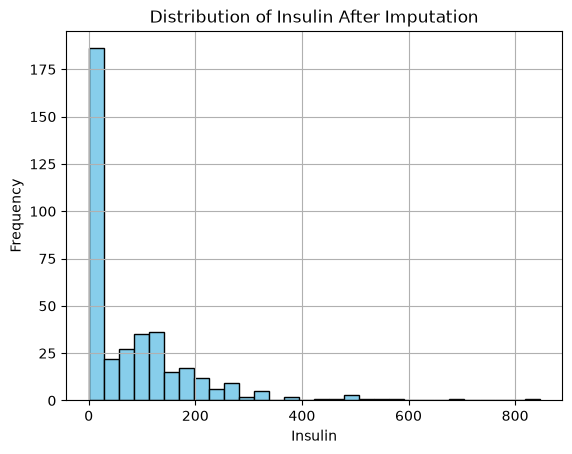

In [13]:
import matplotlib.pyplot as plt

plt.hist(df['Insulin'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Insulin After Imputation')
plt.xlabel('Insulin')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [14]:
(df[zero_cols] == 0).sum()


0
Glucose            2
BloodPressure     19
BMI                5
SkinThickness    106
dtype: int64

بررسی مقادیر NAN

In [15]:
df.isna().sum()


0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [16]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Glucose'])  
y = df['Glucose']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_test_scaled,X_train_scaled)


[[-1.12985597e+00 -3.97919883e-01 -1.28838923e+00 -7.02549015e-01
  -1.26774916e+00  8.72499608e-01  2.82319624e+00 -7.20972940e-01]
 [-2.35103306e-01  1.78313155e-01  6.73957406e-01 -7.02549015e-01
   5.92781427e-01 -5.88608762e-01 -4.00352166e-01 -7.20972940e-01]
 [ 3.61398471e-01  4.66429674e-01  3.67340744e-01 -5.14553134e-01
  -3.19478731e-01 -5.16202155e-02  5.91508883e-01 -7.20972940e-01]
 [-8.31605084e-01  5.62468514e-01  1.47116073e+00  4.25426274e-01
   3.04699272e-01 -7.44710083e-01 -7.30972516e-01 -7.20972940e-01]
 [ 6.31475823e-02 -3.01881043e-01 -1.28838923e+00 -7.02549015e-01
   2.08671887e-01 -2.01477484e-01 -6.48317429e-01 -7.20972940e-01]
 [ 2.44915469e+00  7.54546194e-01  7.35280738e-01  1.94704055e-01
  -2.71465038e-01  1.01359080e-01  1.08743941e+00 -7.20972940e-01]
 [-5.33354195e-01  1.13870155e+00 -1.28838923e+00 -7.02549015e-01
   1.25296970e+00  1.21592252e+00  1.74868011e+00 -7.20972940e-01]
 [-1.12985597e+00  5.62468514e-01  6.12634074e-01 -2.49649846e-01
   

Linear Regression

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)


y_pred_lr = lr_model.predict(X_test_scaled)


mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("📊 Linear Regression")
print(f"MSE: {mse_lr:.2f}")
print(f"R² Score: {r2_lr:.2f}")
print(f"MAE: {mae_lr:.2f}")


📊 Linear Regression
MSE: 542.94
R² Score: 0.34
MAE: 18.18


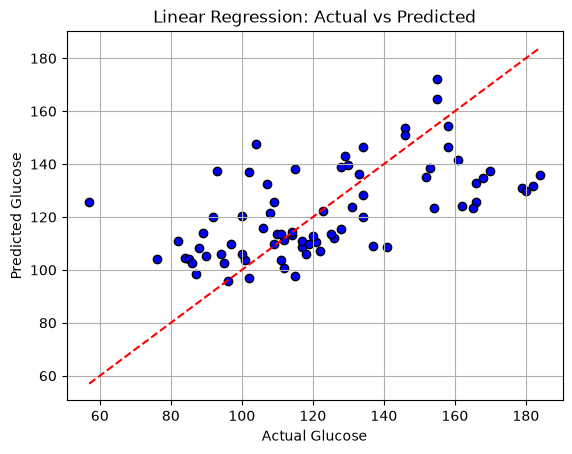

In [18]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr, color='blue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Glucose")
plt.ylabel("Predicted Glucose")
plt.title("Linear Regression: Actual vs Predicted")
plt.grid(True)
plt.show()


Ridge Regression

In [19]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

print("📊 Ridge Regression")
print(f"MSE: {mse_ridge:.2f}")
print(f"R² Score: {r2_ridge:.2f}")
print(f"MAE: {mae_ridge:.2f}")


📊 Ridge Regression
MSE: 542.77
R² Score: 0.34
MAE: 18.18


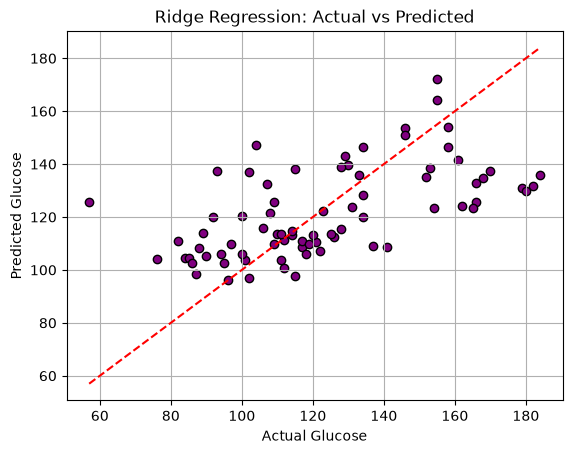

In [20]:
plt.scatter(y_test, y_pred_ridge, color='purple', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Glucose")
plt.ylabel("Predicted Glucose")
plt.title("Ridge Regression: Actual vs Predicted")
plt.grid(True)
plt.show()


Lasso Regression

In [21]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1) 
lasso_model.fit(X_train_scaled, y_train)


y_pred_lasso = lasso_model.predict(X_test_scaled)


mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

print("📊 Lasso Regression")
print(f"MSE: {mse_lasso:.2f}")
print(f"R² Score: {r2_lasso:.2f}")
print(f"MAE: {mae_lasso:.2f}")


📊 Lasso Regression
MSE: 542.15
R² Score: 0.34
MAE: 18.16


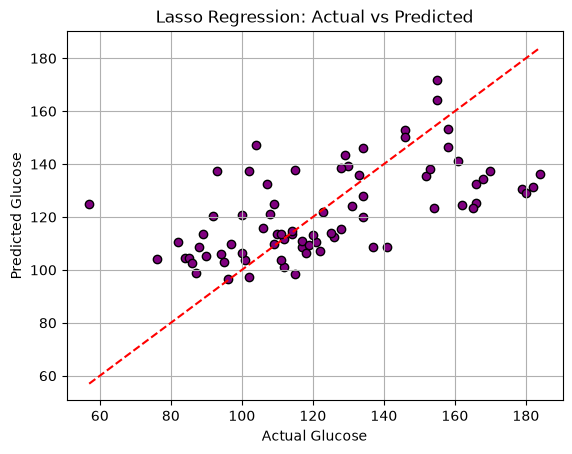

In [22]:
plt.scatter(y_test, y_pred_lasso, color='purple', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Glucose")
plt.ylabel("Predicted Glucose")
plt.title("Lasso Regression: Actual vs Predicted")
plt.grid(True)
plt.show()


effect of hyper parameter

In [23]:

alphas = [0.001, 0.01, 0.1, 1, 10]
results = []

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    nonzero_features = np.sum(model.coef_ != 0)
    
    results.append({
        'alpha': alpha,
        'MSE': mse,
        'R²': r2,
        'Used Features': nonzero_features
    })

results_df = pd.DataFrame(results)
print(results_df)


    alpha         MSE        R²  Used Features
0   0.001  542.928988  0.336420              8
1   0.010  542.846952  0.336520              8
2   0.100  542.145293  0.337377              8
3   1.000  547.043459  0.331391              5
4  10.000  681.148182  0.167485              1


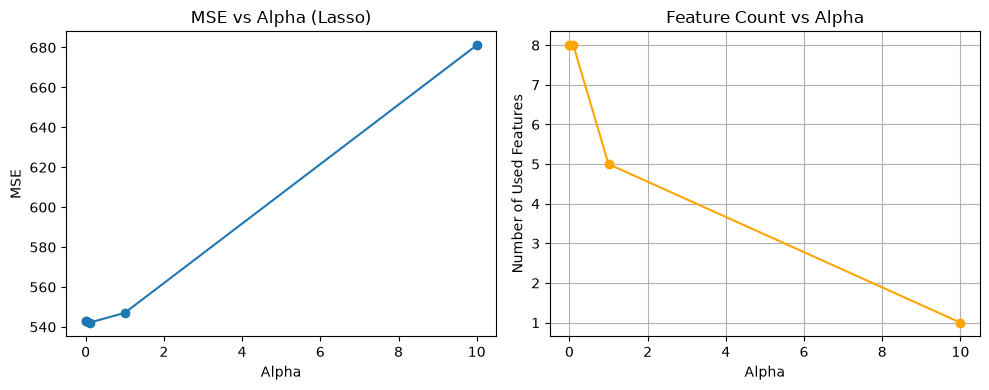

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(results_df['alpha'], results_df['MSE'], marker='o')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('MSE vs Alpha (Lasso)')

plt.subplot(1,2,2)
plt.plot(results_df['alpha'], results_df['Used Features'], marker='o', color='orange')
plt.xlabel('Alpha')
plt.ylabel('Number of Used Features')
plt.title('Feature Count vs Alpha')

plt.tight_layout()
plt.grid(True)
plt.show()


DecisionTreeRegressor

In [25]:
from sklearn.tree import DecisionTreeRegressor


tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train_scaled, y_train)

y_pred_tree = tree_model.predict(X_test_scaled)

mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
mae_tree = mean_absolute_error(y_test, y_pred_tree)

print("🌳 Decision Tree Regressor")
print(f"MSE: {mse_tree:.2f}")
print(f"R² Score: {r2_tree:.2f}")
print(f"MAE: {mae_tree:.2f}")


🌳 Decision Tree Regressor
MSE: 1718.25
R² Score: -1.10
MAE: 29.26


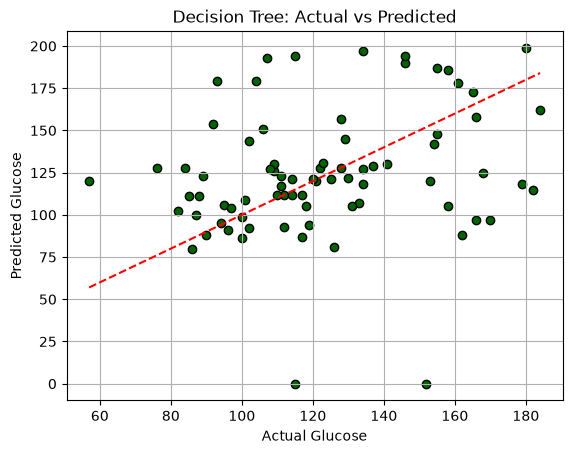

In [26]:
plt.scatter(y_test, y_pred_tree, color='darkgreen', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Glucose")
plt.ylabel("Predicted Glucose")
plt.title("Decision Tree: Actual vs Predicted")
plt.grid(True)
plt.show()


In [27]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

depths = [2, 3, 4, 5, 6, 8, 10, 12]
results = []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Max Depth': depth,
        'MSE': mse,
        'R²': r2
    })

results_df = pd.DataFrame(results)
print(results_df)


   Max Depth          MSE        R²
0          2   486.492580  0.405397
1          3   496.054998  0.393710
2          4   555.260960  0.321347
3          5   681.477336  0.167083
4          6   699.449988  0.145116
5          8  1002.980643 -0.225866
6         10  1078.098334 -0.317677
7         12  1333.922037 -0.630351


changing max depth

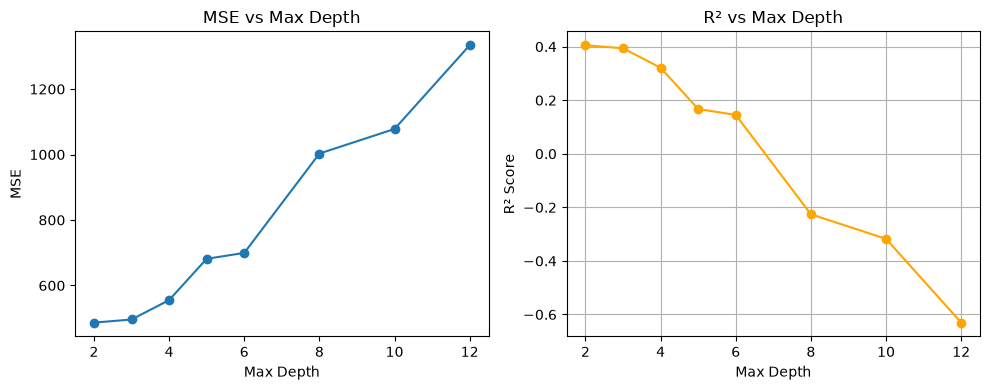

In [28]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(results_df['Max Depth'], results_df['MSE'], marker='o')
plt.xlabel('Max Depth')
plt.ylabel('MSE')
plt.title('MSE vs Max Depth')

plt.subplot(1,2,2)
plt.plot(results_df['Max Depth'], results_df['R²'], marker='o', color='orange')
plt.xlabel('Max Depth')
plt.ylabel('R² Score')
plt.title('R² vs Max Depth')

plt.tight_layout()
plt.grid(True)
plt.show()


RandomForestRegressor

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("🌲 Random Forest Regressor")
print(f"MSE: {mse_rf:.2f}")
print(f"R² Score: {r2_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")


🌲 Random Forest Regressor
MSE: 506.35
R² Score: 0.38
MAE: 17.34


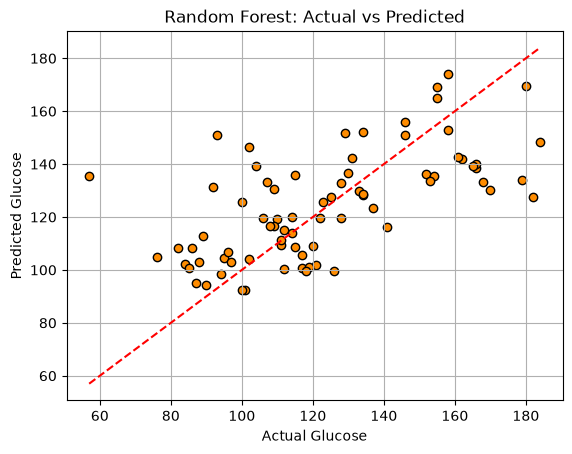

In [30]:
plt.scatter(y_test, y_pred_rf, color='darkorange', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Glucose")
plt.ylabel("Predicted Glucose")
plt.title("Random Forest: Actual vs Predicted")
plt.grid(True)
plt.show()


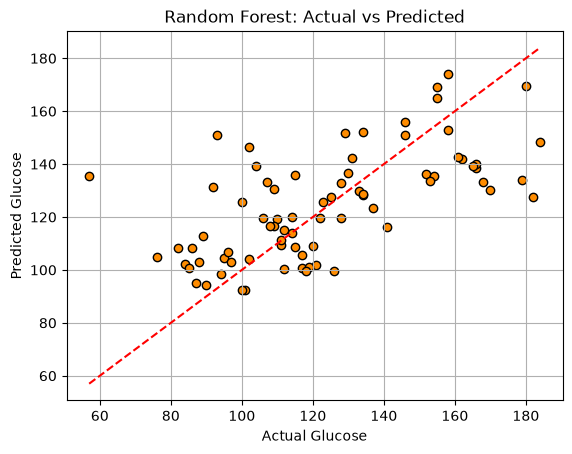

In [31]:


plt.scatter(y_test, y_pred_rf, color='darkorange', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Glucose")
plt.ylabel("Predicted Glucose")
plt.title("Random Forest: Actual vs Predicted")
plt.grid(True)
plt.show()


KNeighborsRegressor

In [32]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)

print("👥 KNN Regressor")
print(f"MSE: {mse_knn:.2f}")
print(f"R² Score: {r2_knn:.2f}")
print(f"MAE: {mae_knn:.2f}")


👥 KNN Regressor
MSE: 703.79
R² Score: 0.14
MAE: 19.05


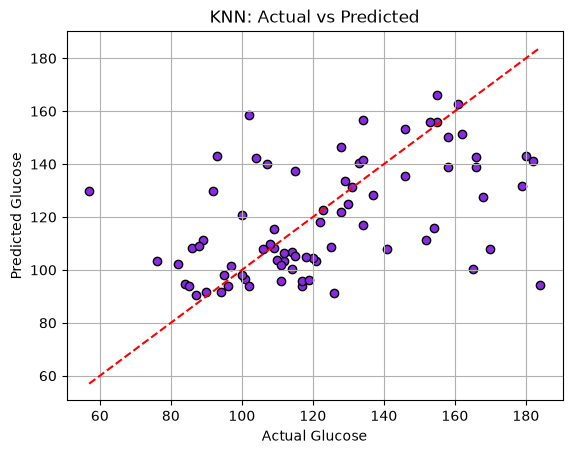

In [33]:
plt.scatter(y_test, y_pred_knn, color='blueviolet', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Glucose")
plt.ylabel("Predicted Glucose")
plt.title("KNN: Actual vs Predicted")
plt.grid(True)
plt.show()


effect of changing k

In [34]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

results = []

for k in range(1, 21):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        'k': k,
        'MSE': mse,
        'R²': r2,
        'MAE': mae
    })

results_df = pd.DataFrame(results)
print(results_df)


     k          MSE        R²        MAE
0    1  1871.441558 -1.287319  29.727273
1    2  1254.685065 -0.533505  25.733766
2    3   886.764791 -0.083825  22.181818
3    4   831.333604 -0.016075  21.237013
4    5   703.790649  0.139811  19.051948
5    6   708.464286  0.134098  18.846320
6    7   702.001590  0.141997  19.116883
7    8   674.463474  0.175655  18.912338
8    9   669.274972  0.181997  19.018759
9   10   685.531299  0.162128  18.822078
10  11   679.506494  0.169491  18.984652
11  12   647.779852  0.208268  18.667749
12  13   643.508415  0.213489  18.632368
13  14   600.185529  0.266439  18.166976
14  15   607.567215  0.257417  18.346320
15  16   595.155793  0.272587  18.163149
16  17   590.743046  0.277980  18.083270
17  18   588.104818  0.281205  18.029582
18  19   580.955787  0.289942  17.904306
19  20   584.714026  0.285349  17.964935


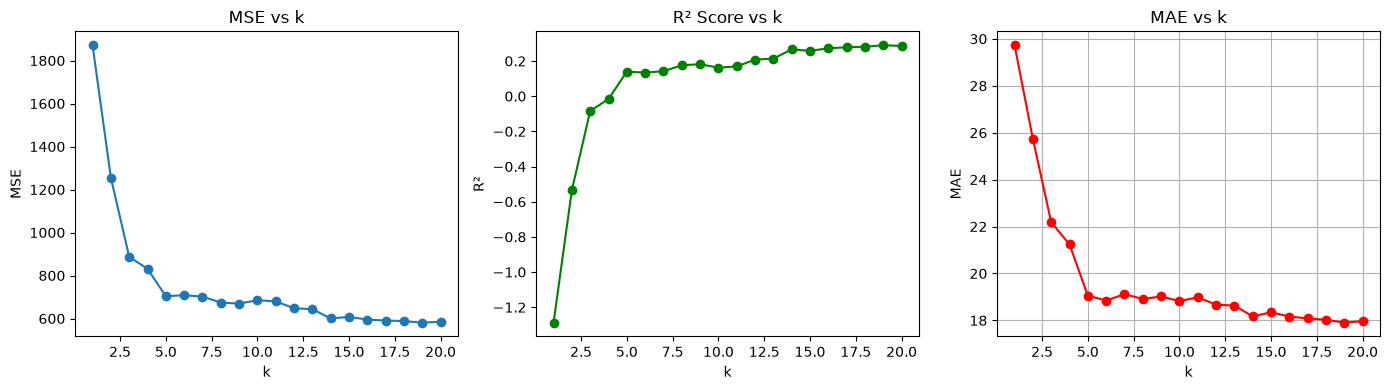

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))

plt.subplot(1, 3, 1)
plt.plot(results_df['k'], results_df['MSE'], marker='o')
plt.title('MSE vs k')
plt.xlabel('k')
plt.ylabel('MSE')

plt.subplot(1, 3, 2)
plt.plot(results_df['k'], results_df['R²'], marker='o', color='green')
plt.title('R² Score vs k')
plt.xlabel('k')
plt.ylabel('R²')

plt.subplot(1, 3, 3)
plt.plot(results_df['k'], results_df['MAE'], marker='o', color='red')
plt.title('MAE vs k')
plt.xlabel('k')
plt.ylabel('MAE')

plt.tight_layout()
plt.grid(True)
plt.show()


poly reg with different degrees


📊 Polynomial Regression (degree=2)
MSE: 619.59
R²: 0.24
MAE: 18.99


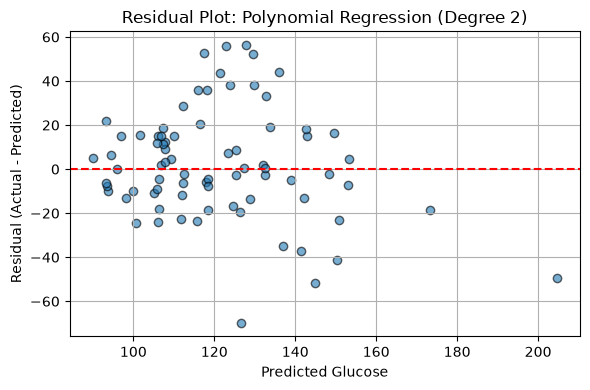


📊 Polynomial Regression (degree=3)
MSE: 1470.92
R²: -0.80
MAE: 25.38


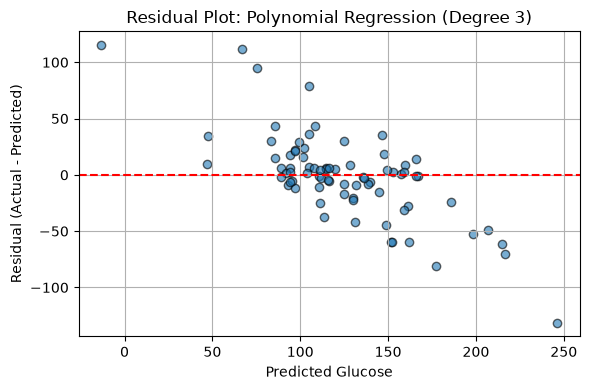

In [36]:
from sklearn.preprocessing import PolynomialFeatures

degrees = [2, 3]

poly_models = {}

for deg in degrees:
    poly = PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    poly_models[deg] = {
        "model": model,
        "y_pred": y_pred,
        "mse": mse,
        "r2": r2,
        "mae": mae
    }
    print(f"\n📊 Polynomial Regression (degree={deg})")
    print(f"MSE: {mse:.2f}")
    print(f"R²: {r2:.2f}")
    print(f"MAE: {mae:.2f}")
    plt.figure(figsize=(6, 4))
    plt.scatter(y_pred, y_test - y_pred, alpha=0.6, edgecolors='k')
    plt.axhline(0, linestyle='--', color='r')
    plt.xlabel("Predicted Glucose")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title(f"Residual Plot: Polynomial Regression (Degree {deg})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    

📊 SVR 
MSE: 719.79
R² Score: 0.12
MAE: 20.41


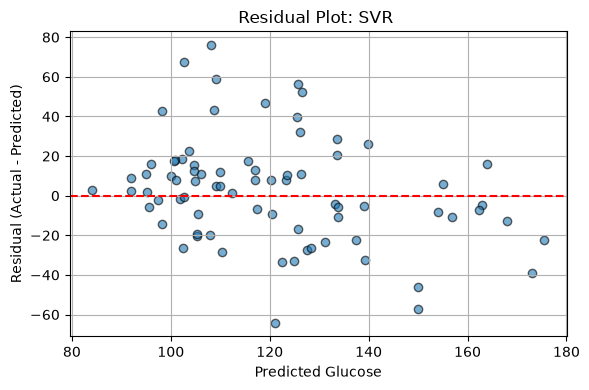

In [37]:
from sklearn.svm import SVR

svr_model_raw = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model_raw.fit(X_train_scaled, y_train)

y_pred_svr_raw = svr_model_raw.predict(X_test_scaled)

mse_raw = mean_squared_error(y_test, y_pred_svr_raw)
r2_raw = r2_score(y_test, y_pred_svr_raw)
mae_raw = mean_absolute_error(y_test, y_pred_svr_raw)

print("📊 SVR ")
print(f"MSE: {mse_raw:.2f}")
print(f"R² Score: {r2_raw:.2f}")
print(f"MAE: {mae_raw:.2f}")

# نمودار باقی‌مانده‌ها
residuals_raw = y_test - y_pred_svr_raw
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_svr_raw, residuals_raw, edgecolors='k', alpha=0.6)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Predicted Glucose")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot: SVR ")
plt.grid(True)
plt.tight_layout()
plt.show()


📊 SVR + PCA
MSE: 633.00
R² Score: 0.23
MAE: 19.58


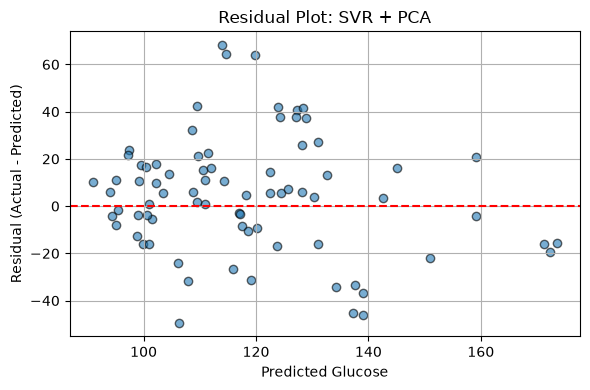

In [38]:
from sklearn.decomposition import PCA
from sklearn.svm import SVR

# کاهش بعد با PCA
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

svr_model_pca = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model_pca.fit(X_train_pca, y_train)

y_pred_svr_pca = svr_model_pca.predict(X_test_pca)

mse_pca = mean_squared_error(y_test, y_pred_svr_pca)
r2_pca = r2_score(y_test, y_pred_svr_pca)
mae_pca = mean_absolute_error(y_test, y_pred_svr_pca)

print("📊 SVR + PCA")
print(f"MSE: {mse_pca:.2f}")
print(f"R² Score: {r2_pca:.2f}")
print(f"MAE: {mae_pca:.2f}")

residuals_pca = y_test - y_pred_svr_pca
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_svr_pca, residuals_pca, edgecolors='k', alpha=0.6)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Predicted Glucose")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot: SVR + PCA")
plt.grid(True)
plt.tight_layout()
plt.show()


📊 KNN Regression + PCA
MSE: 787.40
R² Score: 0.04
MAE: 20.98


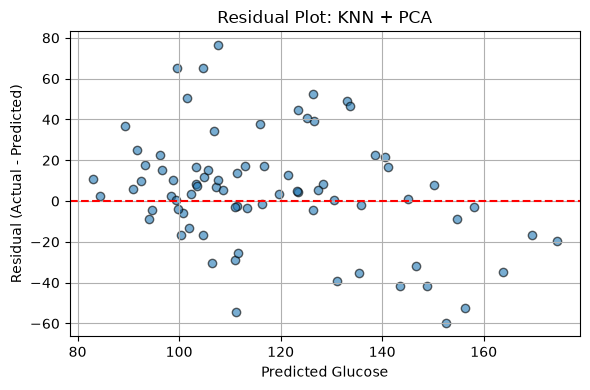

In [39]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# کاهش بعد با PCA (مثلاً 5 مؤلفه)
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# مدل KNN
knn_model_pca = KNeighborsRegressor(n_neighbors=5)
knn_model_pca.fit(X_train_pca, y_train)

# پیش‌بینی
y_pred_knn_pca = knn_model_pca.predict(X_test_pca)

# ارزیابی
mse = mean_squared_error(y_test, y_pred_knn_pca)
r2 = r2_score(y_test, y_pred_knn_pca)
mae = mean_absolute_error(y_test, y_pred_knn_pca)

# چاپ نتایج
print("📊 KNN Regression + PCA")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.2f}")
print(f"MAE: {mae:.2f}")

# نمودار باقی‌مانده‌ها
residuals = y_test - y_pred_knn_pca
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_knn_pca, residuals, edgecolors='k', alpha=0.6)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Predicted Glucose")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot: KNN + PCA")
plt.grid(True)
plt.tight_layout()
plt.show()


In [40]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

models = [
    ('Linear', LinearRegression()),
    ('Ridge', Ridge(alpha=1.0)),
    ('Lasso', Lasso(alpha=0.1, max_iter=10000)),
    ('Decision Tree', DecisionTreeRegressor(max_depth=3, random_state=42)),
    ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('KNN', KNeighborsRegressor(n_neighbors=4)),
    ('SVR', SVR(kernel='rbf', C=100, epsilon=0.1)),
    
    ('SVR + PCA', Pipeline([
        ('pca', PCA(n_components=5)),
        ('svr', SVR(kernel='rbf', C=100, epsilon=0.1))
    ])),

    ('KNN + PCA', Pipeline([
        ('pca', PCA(n_components=5)),
        ('knn', KNeighborsRegressor(n_neighbors=4))
    ]))
]


C:\Users\sama\AppData\Local\Temp\ipykernel_14892\128843981.py:27: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sama\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


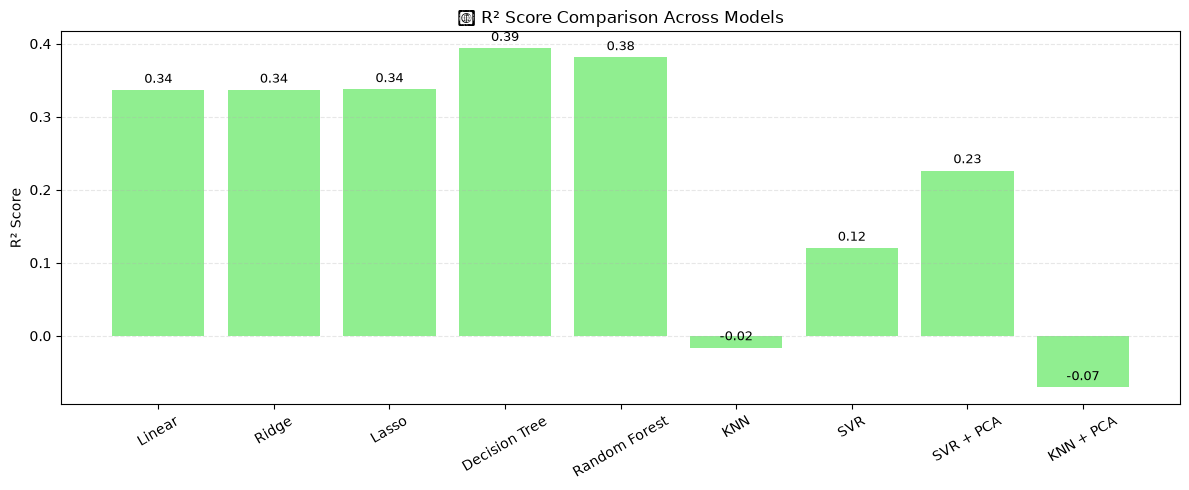

C:\Users\sama\AppData\Local\Temp\ipykernel_14892\128843981.py:39: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sama\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


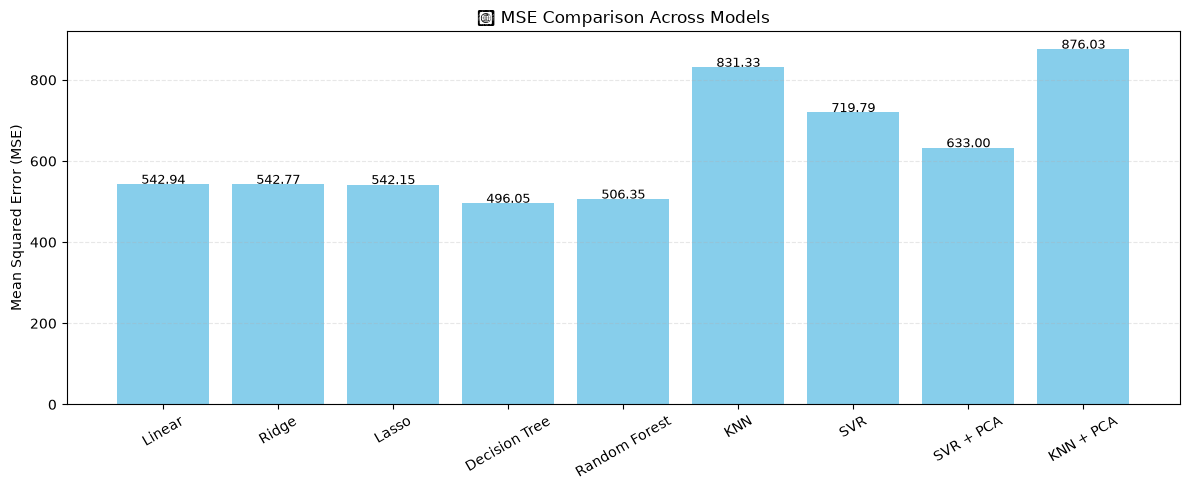

In [41]:


mse_list, r2_list, model_names = [], [], []

# حلقه روی مدل‌ها
for name, model in models:
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    model_names.append(name)
    mse_list.append(mse)
    r2_list.append(r2)

# رسم نمودار مقایسه‌ای MSE و R²
x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x, r2_list, color='lightgreen')
plt.xticks(x, model_names, rotation=30)
plt.ylabel('R² Score')
plt.title('📈 R² Score Comparison Across Models')
for i, v in enumerate(r2_list):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# -------- نمودار MSE --------
plt.figure(figsize=(12, 5))
plt.bar(x, mse_list, color='skyblue')
plt.xticks(x, model_names, rotation=30)
plt.ylabel('Mean Squared Error (MSE)')
plt.title('📉 MSE Comparison Across Models')
for i, v in enumerate(mse_list):
    plt.text(i, v + 1, f'{v:.2f}', ha='center', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()